# Training set compare analysis

General analysis notebook for outputs from `scripts/run_training_set_compare.py`.

This notebook:
- loads merged files if present (otherwise concatenates shard outputs),
- summarizes performance by method / train size / calibration size,
- compares methods against random baseline,
- inspects GA runtime and convergence proxies.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path('../outputs/training_set_compare')
RESULTS_PATH = BASE / 'comparison_results.csv'
SUMMARY_PATH = BASE / 'comparison_summary.csv'

def load_results(base: Path) -> tuple[pd.DataFrame, pd.DataFrame | None]:
    if (base / 'comparison_results.csv').exists():
        results_df = pd.read_csv(base / 'comparison_results.csv')
    else:
        parts = sorted(base.glob('shards/shard_*/**/comparison_results.csv'))
        if not parts:
            raise FileNotFoundError('No comparison_results.csv found in merged output or shards')
        results_df = pd.concat([pd.read_csv(p) for p in parts], ignore_index=True)

    summary_df = pd.read_csv(base / 'comparison_summary.csv') if (base / 'comparison_summary.csv').exists() else None
    return results_df, summary_df

res, summary = load_results(BASE)

print('Results shape:', res.shape)
print('Summary shape:', None if summary is None else summary.shape)
print('Methods:', sorted(res['method'].unique().tolist()))
print('Traits:', sorted(res['trait'].unique().tolist()))
print('Targets:', sorted(res['target_island'].unique().tolist()))

Results shape: (540, 17)
Summary shape: (48, 10)
Methods: ['all_individuals', 'calibration_ga', 'pevmean_ga', 'random']
Traits: ['body_mass']
Targets: [3]


In [12]:
# ---- Filters (edit as needed) ----
TRAITS = None          # e.g. ['body_mass']
TARGETS = None         # e.g. [3]
CAL_SAMPLES = None     # e.g. [25, 50, 100]
TRAIN_SIZES = None     # e.g. [500, 1000, 2000]
METHODS = ['pevmean_ga', 'random', 'all_individuals']      # e.g. ['pevmean_ga', 'calibration_ga', 'random', 'all_individuals']

df = res.copy()
if TRAITS is not None:
    df = df[df['trait'].isin(TRAITS)]
if TARGETS is not None:
    df = df[df['target_island'].isin(TARGETS)]
if CAL_SAMPLES is not None:
    df = df[df['n_cal_samples'].isin(CAL_SAMPLES)]
if TRAIN_SIZES is not None:
    df = df[df['n_train_size'].isin(TRAIN_SIZES)]
if METHODS is not None:
    df = df[df['method'].isin(METHODS)]

print('Filtered rows:', len(df))
display(df.head())

Filtered rows: 465


,method,n_train_size,n_individuals,corr_eval_cal,corr_eval_test,mse_adj_test,pevmean_obj,fitness,target_island,target_island_name,n_cal_samples,repeat,repeat_seed,trait,order_seed,ga_generations,ga_elapsed_sec
0,all_individuals,5503,5503,-0.013444,0.230986,0.946999,16597.565145,-0.000002,3,Selvær,25,0,1743042106,body_mass,-2,0,0.000000
2,pevmean_ga,500,500,0.214527,0.220152,0.950726,18719.066437,0.000429,3,Selvær,25,0,1743042106,body_mass,-1,100,20.966609
3,random,500,500,0.055029,0.159152,0.967176,NaN,0.000110,3,Selvær,25,0,1743042106,body_mass,0,0,0.000000
4,random,500,500,-0.050786,-0.048329,0.996442,NaN,-0.000102,3,Selvær,25,0,1743042106,body_mass,1,0,0.000000
5,random,500,500,-0.319867,0.031562,0.983863,NaN,-0.000640,3,Selvær,25,0,1743042106,body_mass,2,0,0.000000


In [3]:
# ---- Coverage / design sanity ----
coverage = (
    df.groupby(['trait', 'target_island', 'n_cal_samples', 'n_train_size', 'method'], as_index=False)
      .agg(n_rows=('corr_eval_test', 'size'),
           n_repeats=('repeat', 'nunique'),
           n_order_seeds=('order_seed', 'nunique'))
)

method_counts = coverage.groupby('method', as_index=False)['n_rows'].sum().sort_values('n_rows', ascending=False)
display(method_counts)
display(coverage.head(20))

,method,n_rows
3,random,375
1,calibration_ga,75
2,pevmean_ga,75
0,all_individuals,15


,trait,target_island,n_cal_samples,n_train_size,method,n_rows,n_repeats,n_order_seeds
0,body_mass,3,25,500,calibration_ga,5,5,1
1,body_mass,3,25,500,pevmean_ga,5,5,1
2,body_mass,3,25,500,random,25,5,5
3,body_mass,3,25,1000,calibration_ga,5,5,1
4,body_mass,3,25,1000,pevmean_ga,5,5,1
5,body_mass,3,25,1000,random,25,5,5
6,body_mass,3,25,2000,calibration_ga,5,5,1
7,body_mass,3,25,2000,pevmean_ga,5,5,1
8,body_mass,3,25,2000,random,25,5,5
9,body_mass,3,25,3000,calibration_ga,5,5,1


In [13]:
# ---- Main performance table ----
perf = (
    df.groupby(['method', 'n_cal_samples', 'n_train_size'], as_index=False)
      .agg(
          corr_test_mean=('corr_eval_test', 'mean'),
          corr_test_std=('corr_eval_test', 'std'),
          corr_cal_mean=('corr_eval_cal', 'mean'),
          mse_test_mean=('mse_adj_test', 'mean'),
          n_rows=('corr_eval_test', 'size')
      )
      .sort_values(['n_cal_samples', 'n_train_size', 'corr_test_mean'], ascending=[True, True, False])
)
display(perf)

,method,n_cal_samples,n_train_size,corr_test_mean,corr_test_std,corr_cal_mean,mse_test_mean,n_rows
3,pevmean_ga,25,500,0.241250,0.033629,0.042619,0.894060,5
18,random,25,500,0.109859,0.072119,-0.006980,0.915641,25
4,pevmean_ga,25,1000,0.215529,0.050304,0.158507,0.892259,5
19,random,25,1000,0.139716,0.075457,0.031928,0.907972,25
5,pevmean_ga,25,2000,0.205555,0.031557,0.215893,0.900793,5
20,random,25,2000,0.174398,0.047584,0.107994,0.902025,25
6,pevmean_ga,25,3000,0.223203,0.023051,0.209069,0.892525,5
21,random,25,3000,0.196473,0.033496,0.141413,0.896537,25
7,pevmean_ga,25,4000,0.213167,0.026402,0.146676,0.894689,5
22,random,25,4000,0.207857,0.027263,0.154485,0.898199,25


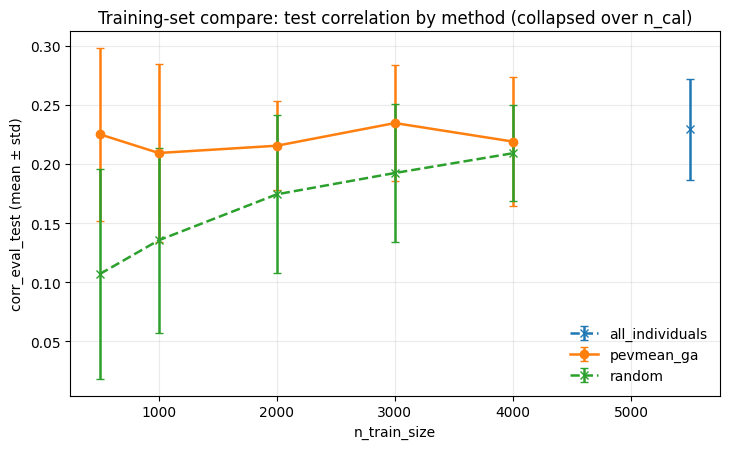

In [14]:
# ---- Plot: corr_test vs n_train_size ----
# If calibration_ga is filtered out, collapse across n_cal_samples and show one figure.

plot_df = perf.copy()
methods_present = set(plot_df['method'].unique().tolist())

# Honor METHODS filter (if defined), even if upstream cells were not rerun in order
methods_filter = None
if 'METHODS' in globals() and METHODS is not None:
    methods_filter = set(METHODS)

if methods_filter is not None:
    collapse_cal = 'calibration_ga' not in methods_filter
else:
    collapse_cal = 'calibration_ga' not in methods_present


def _style_for_method(method: str):
    if method in {'random', 'all_individuals'}:
        return {'linestyle': '--', 'marker': 'x', 'linewidth': 1.8}
    return {'linestyle': '-', 'marker': 'o', 'linewidth': 1.8}


if collapse_cal:
    # Treat all n_cal_samples as one pool: one point per (method, n_train_size)
    one_fig = (
        df.groupby(['method', 'n_train_size'], as_index=False)
          .agg(
              corr_test_mean=('corr_eval_test', 'mean'),
              corr_test_std=('corr_eval_test', 'std'),
              n_rows=('corr_eval_test', 'size')
          )
          .sort_values(['method', 'n_train_size'])
    )

    plt.figure(figsize=(7.4, 4.6))
    for method, sub in one_fig.groupby('method'):
        sub = sub.sort_values('n_train_size')
        st = _style_for_method(method)
        plt.errorbar(
            sub['n_train_size'],
            sub['corr_test_mean'],
            yerr=sub['corr_test_std'].fillna(0.0),
            marker=st['marker'],
            linestyle=st['linestyle'],
            linewidth=st['linewidth'],
            capsize=3,
            label=method,
        )

    plt.xlabel('n_train_size')
    plt.ylabel('corr_eval_test (mean ± std)')
    plt.title('Training-set compare: test correlation by method (collapsed over n_cal)')
    plt.grid(alpha=0.25)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

else:
    # Keep one panel per n_cal_samples
    panel_vals = sorted(plot_df['n_cal_samples'].unique().tolist())
    n_panels = len(panel_vals)

    fig, axes = plt.subplots(1, n_panels, figsize=(5.2 * n_panels, 4.4), sharey=True)
    if n_panels == 1:
        axes = [axes]

    for ax, cal in zip(axes, panel_vals):
        cell = plot_df[plot_df['n_cal_samples'] == cal]
        for method, sub in cell.groupby('method'):
            sub = sub.sort_values('n_train_size')
            st = _style_for_method(method)
            ax.errorbar(
                sub['n_train_size'],
                sub['corr_test_mean'],
                yerr=sub['corr_test_std'].fillna(0.0),
                marker=st['marker'],
                linestyle=st['linestyle'],
                linewidth=st['linewidth'],
                capsize=3,
                label=method,
            )
        ax.set_title(f'n_cal_samples = {cal}')
        ax.set_xlabel('n_train_size')
        ax.grid(alpha=0.25)

    axes[0].set_ylabel('corr_eval_test (mean ± std)')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.03), ncol=min(4, len(labels)), frameon=False)
    fig.suptitle('Training-set compare: test correlation by method', y=1.08)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

In [6]:
# ---- Gain over random baseline (paired within same setting) ----
keys = ['trait', 'target_island', 'n_cal_samples', 'n_train_size', 'repeat', 'repeat_seed']

random_mean = (
    df[df['method'] == 'random']
      .groupby(keys, as_index=False)['corr_eval_test']
      .mean()
      .rename(columns={'corr_eval_test': 'corr_random_mean'})
)

opt_methods = ['pevmean_ga', 'calibration_ga', 'all_individuals']
gains = []
for m in opt_methods:
    sub = df[df['method'] == m][keys + ['corr_eval_test']].copy()
    sub = sub.rename(columns={'corr_eval_test': 'corr_method'})
    merged = sub.merge(random_mean, on=keys, how='inner')
    merged['method'] = m
    merged['gain_vs_random'] = merged['corr_method'] - merged['corr_random_mean']
    gains.append(merged)

gain_df = pd.concat(gains, ignore_index=True) if gains else pd.DataFrame()

gain_summary = (
    gain_df.groupby(['method', 'n_cal_samples', 'n_train_size'], as_index=False)
      .agg(
          gain_mean=('gain_vs_random', 'mean'),
          gain_std=('gain_vs_random', 'std'),
          frac_positive=('gain_vs_random', lambda s: float(np.mean(s > 0))),
          n=('gain_vs_random', 'size')
      )
      .sort_values(['n_cal_samples', 'n_train_size', 'gain_mean'], ascending=[True, True, False])
)

display(gain_summary)

,method,n_cal_samples,n_train_size,gain_mean,gain_std,frac_positive,n
15,pevmean_ga,25,500,0.131391,0.034399,1.0,5
0,calibration_ga,25,500,-0.091441,0.106638,0.2,5
16,pevmean_ga,25,1000,0.075813,0.071613,0.8,5
1,calibration_ga,25,1000,-0.044395,0.037476,0.0,5
17,pevmean_ga,25,2000,0.031157,0.034829,0.8,5
2,calibration_ga,25,2000,-0.031706,0.057730,0.2,5
18,pevmean_ga,25,3000,0.026730,0.023064,0.8,5
3,calibration_ga,25,3000,-0.057152,0.044605,0.0,5
19,pevmean_ga,25,4000,0.005310,0.012767,0.8,5
4,calibration_ga,25,4000,-0.019258,0.020353,0.2,5


,method,n_cal_samples,n_train_size,elapsed_mean,elapsed_std,gens_mean,corr_test_mean,n
0,calibration_ga,25,500,307.498545,36.370458,100.0,0.018419,5
1,calibration_ga,25,1000,750.863372,28.825289,100.0,0.095322,5
2,calibration_ga,25,2000,1464.249952,146.506959,100.0,0.142693,5
3,calibration_ga,25,3000,2080.104140,162.023273,100.0,0.139320,5
4,calibration_ga,25,4000,3027.011754,298.134327,100.0,0.188598,5
5,calibration_ga,50,500,309.801036,37.274640,100.0,0.132705,5
6,calibration_ga,50,1000,763.792021,28.710693,100.0,0.144624,5
7,calibration_ga,50,2000,1476.549523,152.837006,100.0,0.103890,5
8,calibration_ga,50,3000,2141.076063,239.470915,100.0,0.140091,5
9,calibration_ga,50,4000,3031.173319,292.249102,100.0,0.189159,5


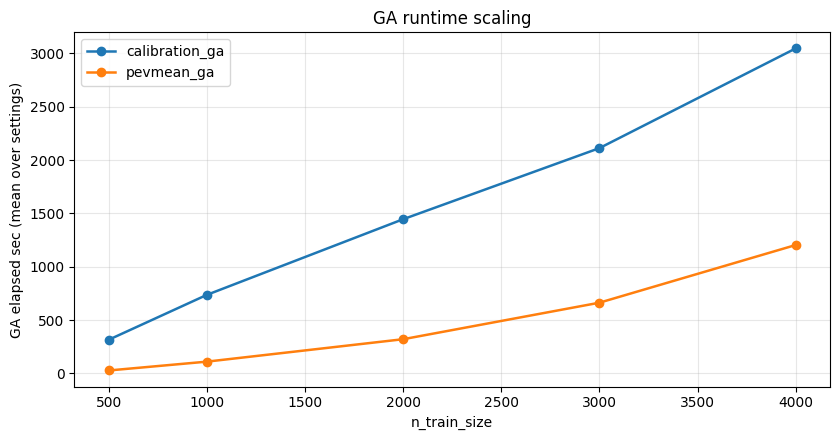

In [7]:
# ---- Runtime diagnostics for GA methods ----
ga_df = df[df['method'].isin(['pevmean_ga', 'calibration_ga'])].copy()
runtime_summary = (
    ga_df.groupby(['method', 'n_cal_samples', 'n_train_size'], as_index=False)
        .agg(
            elapsed_mean=('ga_elapsed_sec', 'mean'),
            elapsed_std=('ga_elapsed_sec', 'std'),
            gens_mean=('ga_generations', 'mean'),
            corr_test_mean=('corr_eval_test', 'mean'),
            n=('ga_elapsed_sec', 'size')
        )
        .sort_values(['method', 'n_cal_samples', 'n_train_size'])
)
display(runtime_summary)

plt.figure(figsize=(8.5, 4.5))
for method, sub in runtime_summary.groupby('method'):
    sub2 = sub.groupby('n_train_size', as_index=False)['elapsed_mean'].mean().sort_values('n_train_size')
    plt.plot(sub2['n_train_size'], sub2['elapsed_mean'], marker='o', linewidth=1.8, label=method)

plt.xlabel('n_train_size')
plt.ylabel('GA elapsed sec (mean over settings)')
plt.title('GA runtime scaling')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()